# HW 6a

## 2D Ising Model Simulation

In [4]:
import numpy as np
import matplotlib.pyplot as plt

### Methods

I implemented a 2D Ising Model simulation. This simulation uses an $L \times L$ grid of spins intialized in either a 'hot' mode, where all spins are random, or 'cold' mode where all spins are initialized to 1. We use the Hamiltonian $H = - \sum s_i s_j$ and use a monte carlo method to flip the spins are each step. The spins are updated using the metorpolis algorithm which works as follows.

1. Choose a random spin
2. Compute the energy change if the spin is fliped $\Delta E = 2 J s_i \sum s_j$
3. Fip the spin with probability $P = \min(1, \exp(-\beta \Delta E))$
4. Repeat for all spins to conduct one sweep.
5. Repeat for enough sweeps to ensure the lattice has reached an equilbirum state.

Using this algorithm we can extract information about the critical temperature of the spin lattice.

### Part 1: Code

In [5]:
def init_lattice(L1, L2, mode='hot'):
    """
    Description
    -----------
    Initialize the 2D Ising spin lattice.

    Parameters
    ----------
    L1 : int
        Number of spins in the x-dimension.
    L2 : int
        Number of spins in the y-dimension.
    mode : str, optional
        Initialization mode for the spins.
        'hot'  : spins are randomly assigned values of -1 or +1.
        'cold' : all spins are initialized to +1.
        Default is 'hot'.

    Returns
    -------
    spins : numpy.ndarray
        A 2D array of shape (L1, L2) containing spin values (-1 or +1).
    """
    if mode == 'hot':
        spins = np.random.choice([-1, 1], size=(L1, L2))
    elif mode == 'cold':
        spins = np.ones((L1, L2), dtype=int)
    else:
        raise ValueError("mode must be 'hot' or 'cold'")
    
    return spins

def energy(spins):
    """
    Description
    -----------
    Compute the total energy of a 2D Ising spin configuration. Assumes J = 1 and h = 0

    Parameters
    ----------
    spins : numpy.ndarray
        A 2D array of shape (L1, L2) containing spin values {-1, +1}.

    Returns
    -------
    E : float
        The total energy of the lattice configuration.
    """
    nn = (np.roll(spins,1,0) + np.roll(spins,-1,0) +
          np.roll(spins,1,1) + np.roll(spins,-1,1))
    
    E = -1*np.sum(spins * nn) / 2

    return E

def magnetization(spins):
    """
    Description
    -----------
    Compute the total magnetization of a 2D Ising spin configuration.

    Parameters
    ----------
    spins : numpy.ndarray
        A 2D array of shape (L1, L2) containing spin values {-1, +1}.

    Returns
    -------
    M : int
        The total magnetization of the lattice, defined as the sum
        of all spins.
    """
    return np.sum(spins)

def sweep_metropolis_checkerboard(spins, beta):
    """
    Description
    -----------
    Perform one Metropolis sweep of the 2D Ising lattice using
    checkerboard updates.

    Parameters
    ----------
    spins : numpy.ndarray
        A 2D array of shape (L1, L2) containing spin values {-1, +1}.
        This array is updated in-place.
    beta : float
        Inverse temperature

    Returns
    -------
    None
        The spin lattice is modified directly.
    """

    L1, L2 = spins.shape

    checker = (np.indices((L1, L2)).sum(axis=0) % 2)

    for parity in [0, 1]:

        nn = (
            np.roll(spins,1,0) + np.roll(spins,-1,0) +
            np.roll(spins,1,1) + np.roll(spins,-1,1)
        )

        dE = 2 * spins * nn

        mask = checker == parity

        rand = np.random.rand(L1, L2)

        accept = (dE <= 0) | (rand < np.exp(-beta * dE))

        flip = mask & accept

        spins[flip] *= -1

def run_ising(L, beta, n_therm=1000, n_sweeps=5000, mode='hot'):
    """
    Description
    -----------
    Run a Metropolis simulation of the 2D Ising model.

    Parameters
    ----------
    L : int
        Linear size of the lattice. The simulation uses an L × L lattice.
    beta : float
        Inverse temperature
    n_therm : int, optional
        Number of Monte Carlo sweeps used for thermalization before
        measurements are taken. Default is 1000.
    n_sweeps : int, optional
        Number of Monte Carlo sweeps used to collect measurements
        after thermalization. Default is 5000.
    mode : str, optional
        Initial configuration of the lattice.
        'hot'  : random spins (-1 or +1).
        'cold' : all spins initialized to +1.
        Default is 'hot'.

    Returns
    -------
    energies : numpy.ndarray
        Array containing the total energy of the lattice recorded
        after each measurement sweep.
    mags : numpy.ndarray
        Array containing the total magnetization of the lattice
        recorded after each measurement sweep.
    abs_mags : numpy.ndarray
        Array containing the  absolute value of the total magnetization of the lattice
        recorded after each measurement sweep.
    accept_rates : numpy.ndarray
        Array containing the acceptance rate of the spin flipping
        recorded after each measurement sweep.
    """
    spins = init_lattice(L, L, mode)

    energies = []
    mags = []
    abs_mags = []
    accept_rates = []

    N = L * L

    for i in range(n_therm):

        sweep_metropolis_checkerboard(spins, beta)

    for i in range(n_sweeps):

        before = spins.copy()

        sweep_metropolis_checkerboard(spins, beta)

        flips = np.sum(before != spins)
        accept_rates.append(flips / N)

        E = energy(spins)
        M = magnetization(spins)

        energies.append(E)
        mags.append(M)
        abs_mags.append(np.abs(M) / N)

    return np.array(energies), np.array(mags), np.array(abs_mags), np.array(accept_rates)

def summarize_observables(E, M, N):
    """
    Description
    -----------
    Compute thermodynamic observables from measured energies and magnetizations.

    Parameters
    ----------
    E : numpy.ndarray
        Array of total energy measurements collected during the simulation.
    M : numpy.ndarray
        Array of total magnetization measurements collected during the simulation.
    beta : float
        Inverse temperature defined as beta = 1 / T (with k_B = 1).
    N : int
        Total number of spins in the lattice (N = L1 * L2).

    Returns
    -------
    dict:
        A dictionary containing the following observables:

        energy_per_spin : float
            Average energy per spin ⟨E⟩ / N.

        magnetization_per_spin : float
            Average absolute magnetization per spin ⟨|M|⟩ / N.

    """
    energy_mean = np.mean(E) / N
    mag_mean = np.mean(np.abs(M)) / N

    return {"energy_per_spin": energy_mean, "magnetization_per_spin": mag_mean}

### Part 2: Thermalization Study

In [ ]:
def make_thermalization_plots(E, M, M_abs, accept_rates, N, T):
    """
    Description
    -----------
    Generate plots to evaluate thermalization.

    Parameters
    ----------
    E : array-like
        Energy of the system recorded at each Monte Carlo sweep.

    M : array-like
        Magnetization of the system recorded at each Monte Carlo sweep.

    M_abs : array-like
        Absolute magnetization |M|/N recorded at each Monte Carlo sweep.

    accept_rates : array-like
        Fraction of proposed spin flips that were accepted in each sweep.

    N : int
        Total number of spins in the lattice.

    T : float
        Temperature of the simulation (used for plot title).

    Returns
    -------
    None
        Displays a 2x2 grid of plots showing the evolution of observables.
    """
    sweeps = np.arange(len(E))
    running_avg_M_abs = np.cumsum(M_abs) / np.arange(1, len(M_abs) + 1)

    plt.figure(figsize=(10,8))

    plt.subplot(2,2,1)
    plt.plot(sweeps, E/N)
    plt.title("Energy per spin")

    plt.subplot(2,2,2)
    plt.plot(sweeps, M/N)
    plt.ylim(-1, 1)
    plt.title("Magnetization per spin")

    plt.subplot(2,2,3)
    plt.plot(sweeps, M_abs, alpha=0.4, label="|M|/N")
    plt.plot(sweeps, running_avg_M_abs, label="Running average")
    plt.ylim(0, 1)
    plt.title("|M|/N")
    plt.legend()

    plt.subplot(2,2,4)
    plt.plot(sweeps, accept_rates)
    plt.title("Acceptance rate")

    plt.suptitle(f'T = {T}')
    plt.tight_layout()
    plt.show()

    return

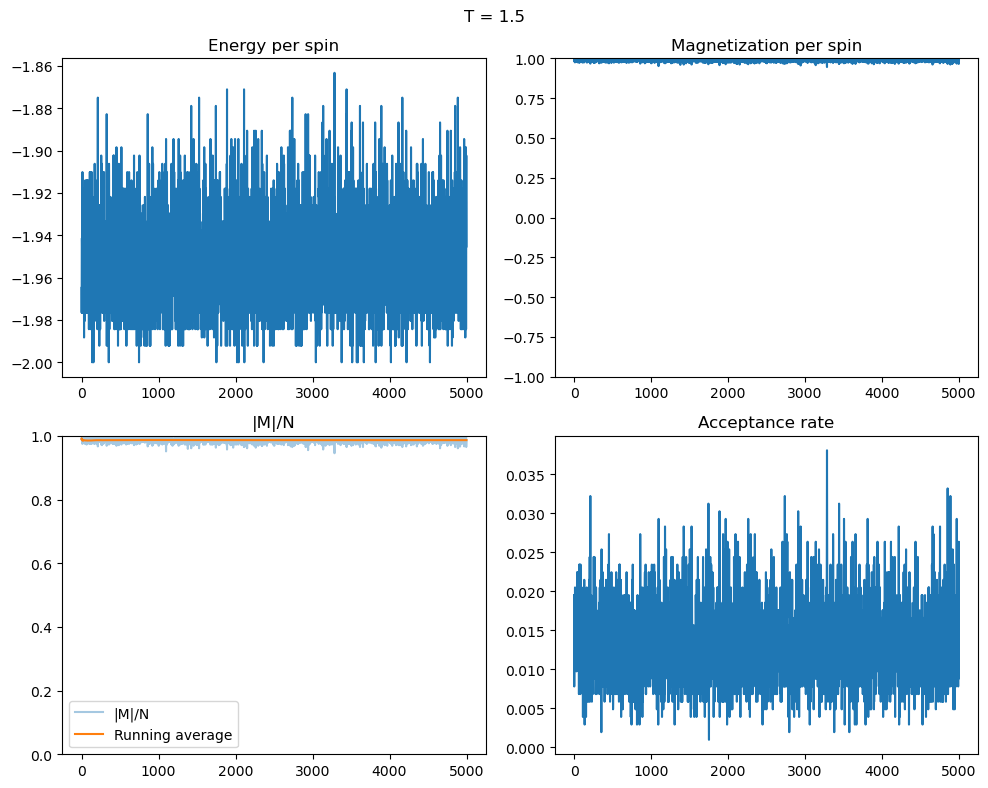

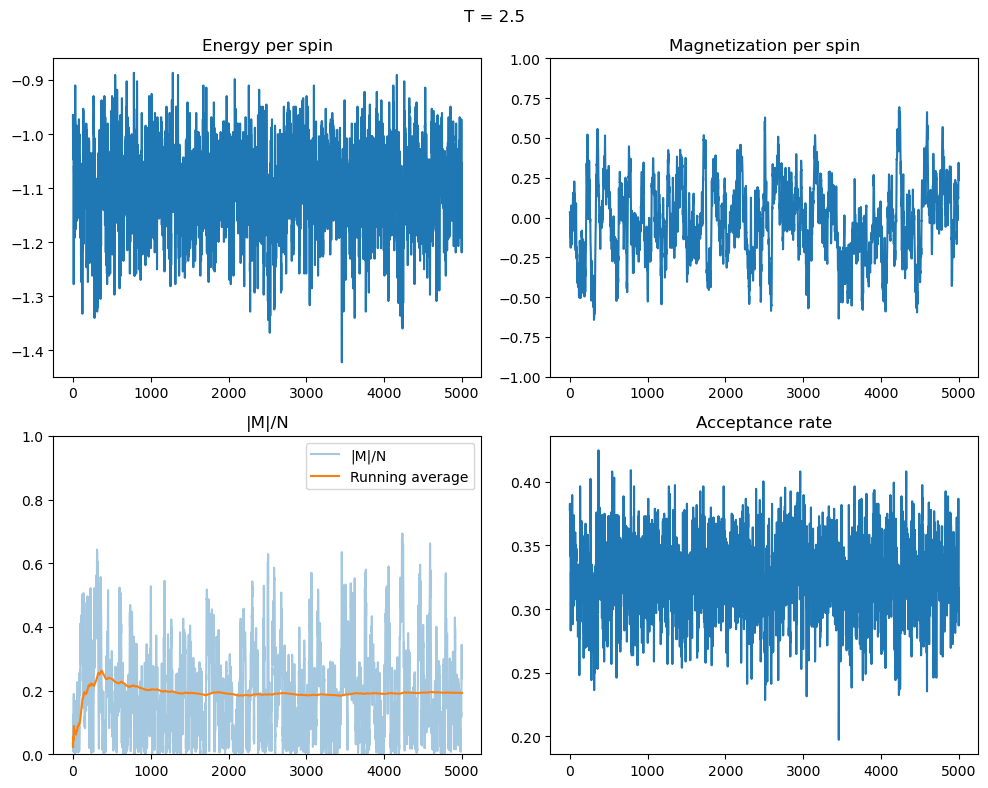

In [38]:
L = 32
T_below = 1.5
T_above = 2.5
beta_below = 1 / T_below
beta_above = 1 / T_above
N = L * L

E_below, M_below, M_abs_below, accept_rates_below = run_ising(L, beta_below)
E_above, M_above, M_abs_above, accept_rates_above = run_ising(L, beta_above)

make_thermalization_plots(E_below, M_below, M_abs_below, accept_rates_below, N, T_below)
make_thermalization_plots(E_above, M_above, M_abs_above, accept_rates_above, N, T_above)


We discarded the first 1000 sweeps before recording data to account for the system not being thermalized. We can determine that equilibium is reached once the graphs converge. This is most noticable for the magnetization plot where we can use the running average flatten out to determine convergence.

### Part 3: Susceptibility and Heat Capacity

In [29]:
def compute_susceptibility_heat_capacity(E, M, N, beta):
    """
    Description
    -----------
    Compute magnetic susceptibility and heat capacity from Monte Carlo time series.

    Parameters
    ----------
    E : numpy.ndarray
        Array of total energy measurements after thermalization.
    M : numpy.ndarray
        Array of total magnetization measurements after thermalization.
    N : int
        Total number of spins in the lattice.
    beta : float
        Inverse temperature.

    Returns
    -------
    chi : float
        Magnetic susceptibility
    Cv : float
        Heat capacity
    """

    m = M / N
    e = E / N

    chi = beta * N * (np.mean(m**2) - np.mean(np.abs(m))**2)
    Cv = beta**2 * N * (np.mean(e**2) - np.mean(e)**2)

    return chi, Cv

In [ ]:
T_values = np.linspace(2.1, 2.5, 50)
L = 32
N = L * L
n_therm = 1000
n_sweeps = 5000

chi_vals = []
Cv_vals = []

for T in T_values:
    
    beta = 1 / T
    E, M, M_abs, accept_rates = run_ising(L, beta, n_therm=n_therm, n_sweeps=n_sweeps, mode='hot')
    
    chi, Cv = compute_susceptibility_heat_capacity(E, M, N, beta)
    chi_vals.append(chi)
    Cv_vals.append(Cv)

chi_vals = np.array(chi_vals)
Cv_vals = np.array(Cv_vals)

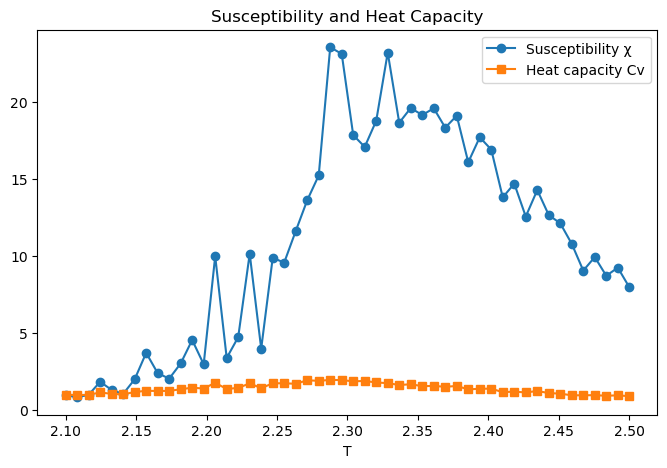

Estimated Tc from susceptibility peak: 2.288


In [37]:
plt.figure(figsize=(8,5))
plt.plot(T_values, chi_vals, 'o-', label="Susceptibility χ")
plt.plot(T_values, Cv_vals, 's-', label="Heat capacity Cv")
plt.xlabel("T")
plt.title("Susceptibility and Heat Capacity")
plt.legend()
plt.show()

Tc_est = T_values[np.argmax(chi_vals)]
print(f"Estimated Tc from susceptibility peak: {Tc_est:.3f}")

### Part 4: Binder Cumulant

In [39]:
def binder_cumulant(M, N):
    """
    Description
    -----------
    Compute Binder cumulant U4 from magnetization time series.

    Parameters
    ----------
    M : numpy.ndarray
        Array of total magnetization measurements after thermalization.
    N : int
        Total number of spins.

    Returns
    -------
    U4 : float
        Binder cumulant.
    """

    m = M / N

    m2 = np.mean(m**2)
    m4 = np.mean(m**4)

    U4 = 1 - m4 / (3 * m2**2)

    return U4

In [44]:
def scan_binder(L, T_values, n_therm=1000, n_sweeps=5000):

    N = L * L
    U_vals = []

    for T in T_values:

        beta = 1 / T

        E, M, M_abs, accept_rates = run_ising(L, beta, n_therm=n_therm, n_sweeps=n_sweeps)

        U = binder_cumulant(M, N)

        U_vals.append(U)

    return np.array(U_vals)

In [48]:
L_values = [16, 24, 32, 48]
T_values = np.linspace(2.1, 2.5, 25)

binder_results = {}

for L in L_values:

    binder_results[L] = scan_binder(L, T_values)

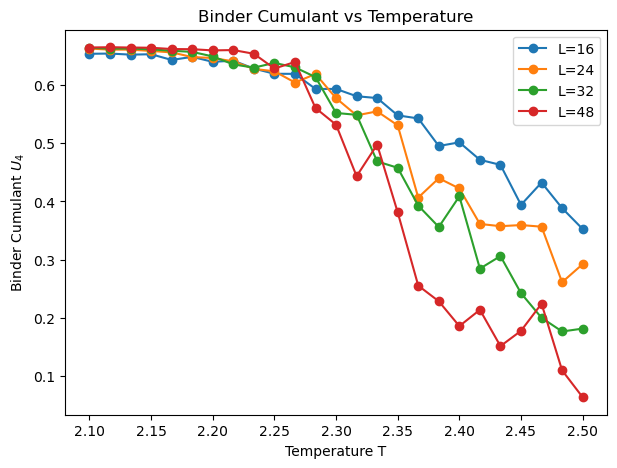

In [49]:
plt.figure(figsize=(7,5))

for L in L_values:
    plt.plot(T_values, binder_results[L], marker='o', label=f"L={L}")

plt.xlabel("Temperature T")
plt.ylabel("Binder Cumulant $U_4$")
plt.title("Binder Cumulant vs Temperature")
plt.legend()
plt.show()

In [50]:
def crossing_temperature(T, U1, U2):

    diff = U1 - U2
    idx = np.argmin(np.abs(diff))

    return T[idx]

In [52]:
Tc_16_32 = crossing_temperature(T_values, binder_results[16], binder_results[32])

Tc_24_48 = crossing_temperature(T_values, binder_results[24], binder_results[48])

print(f'Crossing (16,32): {Tc_16_32}')
print(f'Crossing (24,48): {Tc_24_48}')

Crossing (16,32): 2.2333333333333334
Crossing (24,48): 2.1


Finite size drift ocurs becasue our lattice is finite size so we should only recover the exact critical temperature in the limit where L goes to infinity. We would expect the result to become closer to T_c as L increases but for some reason the crossing temperature for the larger pair is slightly lower. I am not sure why

### Part 5: Analysis

1. Binder cumulant removes the leading finite-size effect as both the numerator and demononator scale by the same effect in the leading order. This reduces the finite size effect and allows us to estimate the T_c.

2. If we used |m| we would lose the effect of the bimodal distribution of m below T_c as the peaks would be combined into one peak. This would lead to a poor estimation of the binder cumulant and therefore T_c

3. Near T_c autocorrolation time decreases which leads to large scale spin flucuations. This can be seen on the magnetization plot where a large portion of the lattice will flip spins Therefore you have to run the simulation for more sweeps to get convergence.

4. This occurs becasue the correlation length of the psins cannot exceed the size of the system. Therefore the estimate for T_c changes. As L goes to infinity the system will produce a more accurate estimate of T_c

5. For T < T_c ordered phase U_4 is expected to be 2/3. This is becaseu the magnetization distribution is bimondal with points at +/- m_0. For disordered phase U_4 is expected to be 0 as the magnetization distriubtion flucuates randomly and is centered around 0. For T = T_c at criticality U4 is expected to be approximately 0.61. I do not understand why this is the case but aparently it has something to do with universality classes and I honestly have no clue what those are. 